In [92]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy
import pandas as pd
from scipy.io import arff
import statistics

In [93]:
# Logistic regression functions

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1/(1+np.exp(-x))

def compute_gradient(X, y, w, b):
        """
        Args:
          X (ndarray (m,n))
          y (ndarray (m,))
          w (ndarray (n,))
          b (scalar)
        """
        
        m,n = X.shape
        f = sigmoid(X@w + b)
        diff = f - y
        dj_dw = (X.T @ diff) / m
        dj_db = diff.mean()
        
        return dj_dw, dj_db
                
def cost(X, y, w, b):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(m,))
          w (ndarray(n,))
          b (scalar)
        """
        
        m = X.shape[0]
        f = sigmoid(X@w + b)
        f = np.clip(f, 1e-9, 1 - 1e-9)
        cost = -y*np.log(f) - (1-y)*np.log(1-f) 
    
        return cost.mean()

def gradient_descent(X, y, w_in, b_in, alpha, iterations):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(n,))
          w (ndarray(n,))
          b (scalar)
          alpha (scalar)
          iterations (scalar)
        """
        
        J_history = []  
        w = copy.deepcopy(w_in)
        b = b_in
        for i in range(iterations):
                dj_dw, dj_db = compute_gradient(X, y, w, b)
                w -= alpha*dj_dw
                b -= alpha*dj_db
                J = cost(X, y, w, b)
                J_history.append(J)
                if i % math.ceil(iterations / 10) == 0:
                        print(f"Iteration {i:4d}: Cost {J_history[i]}")
        return w, b, J_history

def fit_scaler(X):
    mean = X.mean(axis=0)
    std  = np.clip(X.std(axis=0), 1e-7, None)
    return mean, std

def apply_scaler(X, mean, std):
    # sorry for magic numbers
    # items 4 and 5 are source and destination bytes
    scaled = X.copy()
    scaled[:, :4] = (X[:, :4] - mean[:4]) / std[:4]
    scaled[:, 4:6] = np.log1p(X[:, 4:6])
    scaled[:, 6:] = (X[:, 6:] - mean[6:]) / std[6:]
    return scaled

In [94]:
# Loads training and test data
# Creates a universal label encoder so test and train have common encodings
train_data, meta = arff.loadarff('KDDTrain+.arff')
test_data, test_meta = arff.loadarff('KDDTest+.arff')

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)
for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')
        test_df[col] = test_df[col].str.decode('utf-8')

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    le.fit(df[col])
    df[col] = le.transform(df[col])
    known = set(le.classes_)
    test_df[col] = test_df[col].map(
        lambda v: le.transform([v])[0] if v in known else -1
    )

cats = ['normal', 'anomaly']  # index 0 = normal, index 1 = anomaly
df['class']      = pd.Categorical(df['class'], categories=cats).codes
test_df['class'] = pd.Categorical(test_df['class'], categories=cats).codes

# split training and test data into X and Y
train_X = df.iloc[:, :41].to_numpy(dtype=float)
train_y = df.iloc[:, 41].to_numpy(dtype=float)

test_X = test_df.iloc[:, :41].to_numpy(dtype=float)
test_y = test_df.iloc[:, 41].to_numpy(dtype=float)

mean, std = fit_scaler(train_X)
scaled_train_X = apply_scaler(train_X, mean, std)
scaled_test_X  = apply_scaler(test_X, mean, std)

In [95]:
# init weights and biases...
w_in = np.random.random_sample(train_X[0].shape)
b_in = np.random.random_sample()
alpha = 0.1
iters = 1000

In [96]:
# Fit n-feature training data to model!
w,b,J_history = gradient_descent(scaled_train_X, train_y, w_in, b_in, alpha, iters)
print(f"New weights: {w}, new bias: {b}")

Iteration    0: Cost 1.7266946233708433
Iteration  100: Cost 0.2168438011054261
Iteration  200: Cost 0.1797079090529977
Iteration  300: Cost 0.1565492528528874
Iteration  400: Cost 0.14271446260235857
Iteration  500: Cost 0.13561565641920825
Iteration  600: Cost 0.1313016102767313
Iteration  700: Cost 0.12840486924248434
Iteration  800: Cost 0.1263448289439299
Iteration  900: Cost 0.12489468631486923
New weights: [-1.10098851e-02 -5.98568898e-01  1.14548097e-01  3.65904771e-01
  1.95278068e-03 -1.29851434e-01 -3.82009649e-02  7.53174922e-01
  1.33308689e-02  3.01972043e-01  4.86757930e-02 -9.28087043e-02
  2.16272974e-01  1.13501615e-01 -2.39958662e-01 -2.13771097e-01
 -7.44664731e-02 -3.47440133e-03 -6.46682278e-03  3.37074764e-01
  3.34555029e-01 -3.64753931e-04  9.30336148e-01 -7.04183077e-02
  4.12008300e-01  4.94970929e-01  5.28793452e-01  2.43432831e-01
 -8.99877682e-01 -2.55950735e-01  2.16514244e-01  5.93600893e-01
 -6.65896851e-01  1.73421497e-01  2.42278314e-01  8.14754513e-0

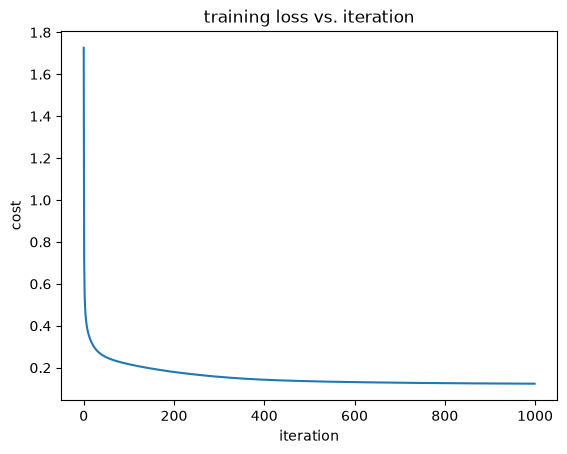

In [97]:
# plot cost vs. iterations
plt.plot(np.arange(len(J_history)), J_history)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("training loss vs. iteration")
plt.show()

In [98]:
# Training cost
train_preds = (sigmoid(scaled_train_X @ w + b) >= 0.5).astype(int)
print((train_preds == train_y).mean())

0.9567843903058592


In [106]:
# Test cost
y_scores = sigmoid(scaled_test_X @ w + b)
preds    = (y_scores >= 0.016633173499329447).astype(int)
print((preds == test_y).mean())

0.86124911284599


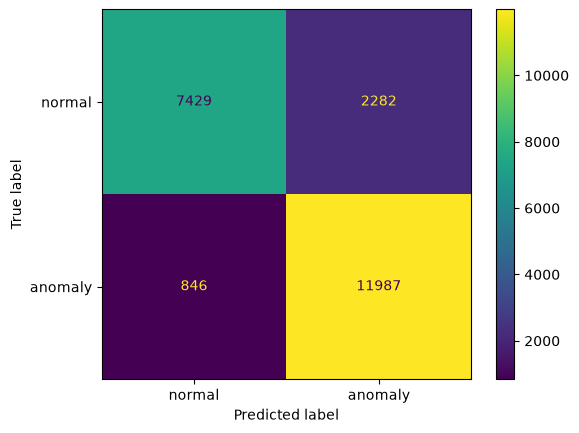

In [107]:
# Creating a confusion matrix on the test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_y, preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=["normal", "anomaly"])
disp.plot()

In [103]:
from sklearn.metrics import classification_report
print(classification_report(test_y, preds, target_names=["normal", "anomaly"]))

              precision    recall  f1-score   support

      normal       0.64      0.93      0.76      9711
     anomaly       0.92      0.59      0.72     12833

    accuracy                           0.74     22544
   macro avg       0.78      0.76      0.74     22544
weighted avg       0.80      0.74      0.74     22544



0.016633173499329447


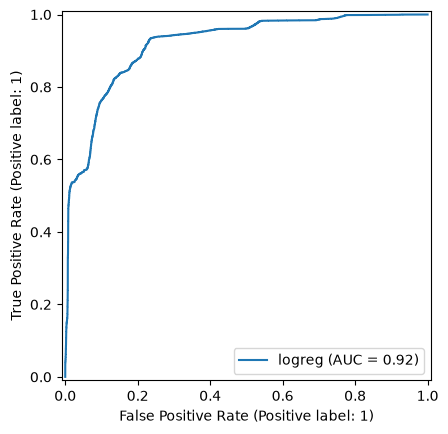

In [105]:
from sklearn.metrics import roc_curve, RocCurveDisplay
RocCurveDisplay.from_predictions(test_y, y_scores, name="logreg")
fpr, tpr, thresholds = roc_curve(test_y, y_scores)
j = np.argmax(tpr - fpr)
best_threshold = thresholds[j]
print(best_threshold)